This notebook explores some basic parts of the data, and examines the ALGO asset mor eclosely. As it has a higher position limit, and lower trading costs, it could serve as a benchmark asset for the other assets.

In [4]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

/var/folders/ny/pgx1yx0d5p5d6bxnkllv_jz40000gn/T/ipykernel_2124/3858623658.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_prices = pd.read_csv("prices.txt", delim_whitespace=True)


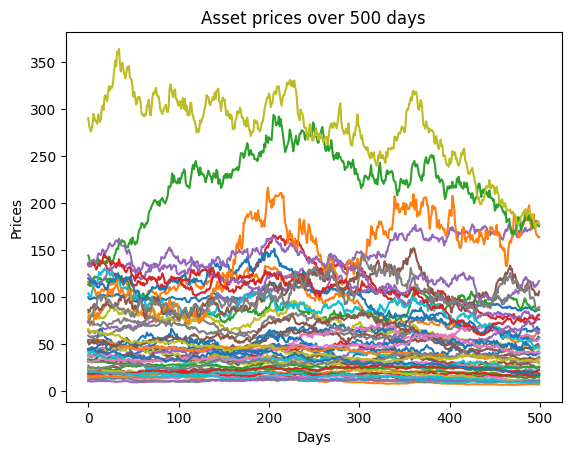

In [5]:
# Load in data 
df_prices = pd.read_csv("prices.txt", delim_whitespace=True)

# Calculate returns
df_returns = df_prices.pct_change()

# Plot the prices of all assets of the 500 days
plt.plot(df_prices)
plt.title("Asset prices over 500 days")
plt.xlabel("Days")
plt.ylabel("Prices")
plt.show()

--- Benchmark Analysis for ALGO ---
Correlation with the rest of the market: 0.9931
Conclusion: Strong evidence it acts as a benchmark/index.

--- Top 5 Assets Most Correlated with ALGO ---
ILVX    0.590823
BENI    0.525946
CUBO    0.522732
DUCT    0.522115
BLBT    0.521960
Name: ALGO, dtype: float64

--- Top 5 Assets Least Correlated with ALGO ---
OTCS    0.356598
ALUT    0.336429
HRND    0.335318
FARS    0.334234
CCNS    0.328013
Name: ALGO, dtype: float64


/var/folders/ny/pgx1yx0d5p5d6bxnkllv_jz40000gn/T/ipykernel_2124/4287441409.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/ny/pgx1yx0d5p5d6bxnkllv_jz40000gn/T/ipykernel_2124/4287441409.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


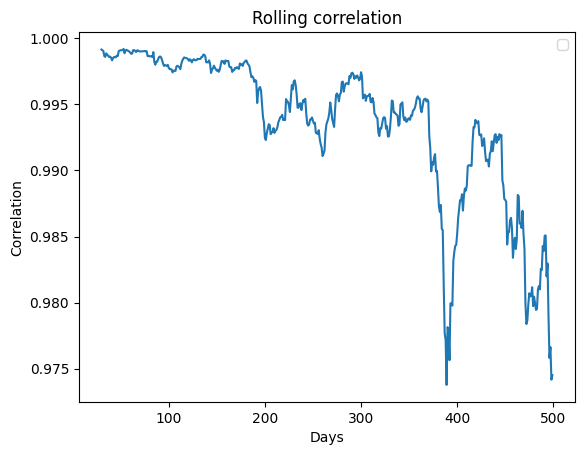

In [7]:
def analyze_benchmark_potential(file_path, benchmark_ticker='ALGO'):
    # 1. Load the data and calculate daily percentage returns
    df = pd.read_csv(file_path, delim_whitespace=True)
    returns = df.pct_change().dropna()

    # 2. Create an equal-weighted "Market Index" of the OTHER 49 assets
    other_assets_returns = returns.drop(columns=[benchmark_ticker])
    market_average_returns = other_assets_returns.mean(axis=1)

    # 3. Calculate the correlation between ALGO and the Market Index
    market_corr = returns[benchmark_ticker].corr(market_average_returns)
    
    # Calculate rolling correlation
    rolling_corr = returns[benchmark_ticker].rolling(window=30).corr(market_average_returns)
    
    print(f"--- Benchmark Analysis for {benchmark_ticker} ---")
    print(f"Correlation with the rest of the market: {market_corr:.4f}")
    
    if market_corr > 0.75:
        print("Conclusion: Strong evidence it acts as a benchmark/index.")
    elif market_corr > 0.50:
        print("Conclusion: Moderate correlation; it captures some market factor but isn't a perfect index.")
    else:
        print("Conclusion: Weak correlation; it behaves like an independent asset, not a benchmark.")

    # 4. Find the best candidates for pairs trading / hedging
    correlations = returns.corr()[benchmark_ticker].sort_values(ascending=False)
    
    print(f"\n--- Top 5 Assets Most Correlated with {benchmark_ticker} ---")
    print(correlations.head(6)[1:]) # Skip the 1.0 correlation with itself
    
    print(f"\n--- Top 5 Assets Least Correlated with {benchmark_ticker} ---")
    print(correlations.tail(5))
    
    # Plot rolling correlation
    plt.plot(rolling_corr)
    plt.title("Rolling correlation")
    plt.ylabel("Correlation")
    plt.xlabel("Days")
    plt.legend()
    plt.show()

# Run the analysis on your cleaned dataset
analyze_benchmark_potential('prices.txt')